# E-Commerce Customer Analysis

## Submitted By
**Samraddhi Joshi**


**B.Tech CSE, 3rd Year**


## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## Project Objective
Analyze customer purchase behavior, ratings, categories, and sales trends.

## Key Insights
- Top-selling product category identified.
- Customer rating trends analyzed.
- Purchase distribution visualized.
- Customer behavior patterns studied.

## Conclusion
The project successfully analyzed e-commerce customer data and generated actionable insights through data cleaning, analysis, and visualization.
-

# 🛒 E-Commerce Customer Analysis
### Data Analysis Project — Python & Jupyter Notebook
**Objective:** Analyze customer orders, product categories, reviews, and shopping patterns from an e-commerce dataset to generate actionable business insights.

---
**Dataset:** `ecommerce_customers.csv`  
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Workflow:** Data Loading → Cleaning → Analysis → Visualization → Insights


## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


## 2. Load Dataset

In [6]:
df = pd.read_csv('ecommerce_customers.csv')
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset Shape: 510 rows × 15 columns


,CustomerID,OrderID,Age,Gender,City,Category,Quantity,PricePerUnit,TotalAmount,Discount(%),FinalAmount,Rating,PaymentMethod,DeliveryDays,OrderDate
0,CUST0001,ORD01001,56,Male,Mumbai,Home & Kitchen,5,416.62,2083.10,0,2083.10,5.0,Debit Card,1,2024-07-11
1,CUST0002,ORD01002,46,Male,Pune,Books,2,308.90,617.80,15,525.13,4.0,Credit Card,5,2024-08-23
2,CUST0003,ORD01003,32,Male,Kolkata,Books,5,1919.90,9599.50,0,9599.50,2.0,Cash on Delivery,5,2024-11-13
3,CUST0004,ORD01004,60,Male,Ahmedabad,Home & Kitchen,1,1402.67,1402.67,20,1122.14,5.0,Cash on Delivery,8,2024-11-11
4,CUST0005,ORD01005,25,Male,Pune,Electronics,3,3265.84,9797.52,10,8817.77,NaN,Debit Card,7,2024-01-18


In [7]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     510 non-null    object 
 1   OrderID        510 non-null    object 
 2   Age            510 non-null    int64  
 3   Gender         510 non-null    object 
 4   City           495 non-null    object 
 5   Category       510 non-null    object 
 6   Quantity       510 non-null    int64  
 7   PricePerUnit   510 non-null    float64
 8   TotalAmount    510 non-null    float64
 9   Discount(%)    510 non-null    int64  
 10  FinalAmount    510 non-null    float64
 11  Rating         485 non-null    float64
 12  PaymentMethod  510 non-null    object 
 13  DeliveryDays   510 non-null    int64  
 14  OrderDate      510 non-null    object 
dtypes: float64(4), int64(4), object(7)
memory usage: 59.9+ KB


In [8]:
# Statistical summary
df.describe()

,Age,Quantity,PricePerUnit,TotalAmount,Discount(%),FinalAmount,Rating,DeliveryDays
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,485.000000,510.000000
mean,41.266667,3.076471,2518.036098,7763.189824,10.921569,6924.710118,3.905155,5.000000
std,13.396605,1.444465,1458.780659,6103.077627,7.640866,5532.778710,1.118623,2.508923
min,18.000000,1.000000,100.920000,109.210000,0.000000,98.290000,1.000000,1.000000
25%,30.250000,2.000000,1208.370000,2842.545000,5.000000,2614.812500,3.000000,3.000000
50%,42.000000,3.000000,2525.340000,5953.410000,10.000000,5366.185000,4.000000,5.000000
75%,52.000000,4.000000,3787.607500,11358.472500,15.000000,10118.010000,5.000000,7.000000
max,64.000000,5.000000,4985.680000,24731.200000,25.000000,23116.350000,5.000000,9.000000


## 3. Data Cleaning & Preprocessing
Steps:
- Check and handle missing values
- Remove duplicate records
- Convert data types
- Feature engineering (Month, Age Group)

In [9]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

        Missing Count  Missing %
City               15       2.94
Rating             25       4.90


In [10]:
# Fill missing Rating with median
df['Rating'].fillna(df['Rating'].median(), inplace=True)

# Fill missing City with mode
df['City'].fillna(df['City'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "missing values remaining")

Missing values after cleaning:
0 missing values remaining


In [11]:
# Check and remove duplicates
print(f"Duplicate rows before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Duplicate rows after: {df.duplicated().sum()}")
print(f"Clean dataset shape: {df.shape}")

Duplicate rows before: 10
Duplicate rows after: 0
Clean dataset shape: (500, 15)


In [12]:
# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Month'] = df['OrderDate'].dt.month
df['MonthName'] = df['OrderDate'].dt.strftime('%b')

# Create Age Group feature
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Convert Rating to int
df['Rating'] = df['Rating'].fillna(df['Rating'].median()).astype(int)

print("Feature engineering done ✅")
df[['Age', 'AgeGroup', 'OrderDate', 'Month', 'MonthName']].head()

Feature engineering done ✅


,Age,AgeGroup,OrderDate,Month,MonthName
0,56,56-65,2024-07-11,7,Jul
1,46,46-55,2024-08-23,8,Aug
2,32,26-35,2024-11-13,11,Nov
3,60,56-65,2024-11-11,11,Nov
4,25,18-25,2024-01-18,1,Jan


## 4. Data Analysis

### 4.1 Category-wise Sales Analysis

In [13]:
category_sales = df.groupby('Category').agg(
    TotalOrders=('OrderID', 'count'),
    TotalRevenue=('FinalAmount', 'sum'),
    AvgOrderValue=('FinalAmount', 'mean'),
    AvgRating=('Rating', 'mean')
).sort_values('TotalRevenue', ascending=False).round(2)

print(category_sales)

                TotalOrders  TotalRevenue  AvgOrderValue  AvgRating
Category                                                           
Electronics             112     741666.53        6622.02       4.06
Clothing                 87     575520.30        6615.18       3.77
Beauty                   74     533992.16        7216.11       3.92
Home & Kitchen           74     490340.06        6626.22       3.95
Books                    53     403798.90        7618.85       3.94
Sports                   52     365302.06        7025.04       3.71
Toys                     48     324201.86        6754.21       3.85


### 4.2 Customer Purchase Behavior by Age Group

In [14]:
age_analysis = df.groupby('AgeGroup').agg(
    NumOrders=('OrderID', 'count'),
    TotalSpend=('FinalAmount', 'sum'),
    AvgSpendPerOrder=('FinalAmount', 'mean')
).round(2)

print(age_analysis)

          NumOrders  TotalSpend  AvgSpendPerOrder
AgeGroup                                         
18-25            90   641452.89           7127.25
26-35            84   553732.07           6592.05
36-45           119   850147.13           7144.09
46-55           116   856217.04           7381.18
56-65            91   533272.74           5860.14


### 4.3 Monthly Revenue Trend

In [15]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('MonthName')['FinalAmount'].sum().reindex(month_order).fillna(0)
print("Monthly Revenue (₹):")
print(monthly.round(2))

Monthly Revenue (₹):
MonthName
Jan    230619.15
Feb    256224.51
Mar    306063.11
Apr    272732.45
May    167957.05
Jun    379108.68
Jul    346617.42
Aug    277541.24
Sep    252433.42
Oct    231055.07
Nov    359013.67
Dec    355456.10
Name: FinalAmount, dtype: float64


### 4.4 Payment Method Analysis

In [16]:
payment_analysis = df['PaymentMethod'].value_counts()
print("Payment Method Distribution:")
print(payment_analysis)

Payment Method Distribution:
PaymentMethod
Cash on Delivery    108
UPI                 108
Net Banking          98
Credit Card          95
Debit Card           91
Name: count, dtype: int64


### 4.5 Rating Distribution & Top/Bottom Products

In [17]:
print("Rating Distribution:")
print(df['Rating'].value_counts().sort_index())

print("\nAverage Rating by Category:")
print(df.groupby('Category')['Rating'].mean().sort_values(ascending=False).round(2))

Rating Distribution:
Rating
1     25
2     34
3     71
4    204
5    166
Name: count, dtype: int64

Average Rating by Category:
Category
Electronics       4.06
Home & Kitchen    3.95
Books             3.94
Beauty            3.92
Toys              3.85
Clothing          3.77
Sports            3.71
Name: Rating, dtype: float64


### 4.6 Delivery Performance

In [18]:
print("Delivery Days Statistics:")
print(df['DeliveryDays'].describe().round(2))

fast = (df['DeliveryDays'] <= 3).sum()
slow = (df['DeliveryDays'] > 6).sum()
print(f"\nFast Deliveries (≤3 days): {fast} ({fast/len(df)*100:.1f}%)")
print(f"Slow Deliveries (>6 days): {slow} ({slow/len(df)*100:.1f}%)")

Delivery Days Statistics:
count    500.00
mean       5.00
std        2.51
min        1.00
25%        3.00
50%        5.00
75%        7.00
max        9.00
Name: DeliveryDays, dtype: float64

Fast Deliveries (≤3 days): 158 (31.6%)
Slow Deliveries (>6 days): 159 (31.8%)


### 4.7 Gender-wise Spending

In [19]:
gender_analysis = df.groupby('Gender').agg(
    NumOrders=('OrderID', 'count'),
    TotalSpend=('FinalAmount', 'sum'),
    AvgSpend=('FinalAmount', 'mean')
).round(2)
print(gender_analysis)

        NumOrders  TotalSpend  AvgSpend
Gender                                 
Female        229  1660991.73   7253.24
Male          271  1773830.14   6545.50


### 4.8 City-wise Revenue

In [20]:
city_rev = df.groupby('City')['FinalAmount'].sum().sort_values(ascending=False)
print("Revenue by City (₹):")
print(city_rev.round(2))

Revenue by City (₹):
City
Pune         664247.37
Kolkata      488354.20
Bangalore    464152.02
Mumbai       455066.01
Hyderabad    365924.73
Chennai      340252.26
Delhi        339911.56
Ahmedabad    316913.72
Name: FinalAmount, dtype: float64


## 5. Data Visualizations

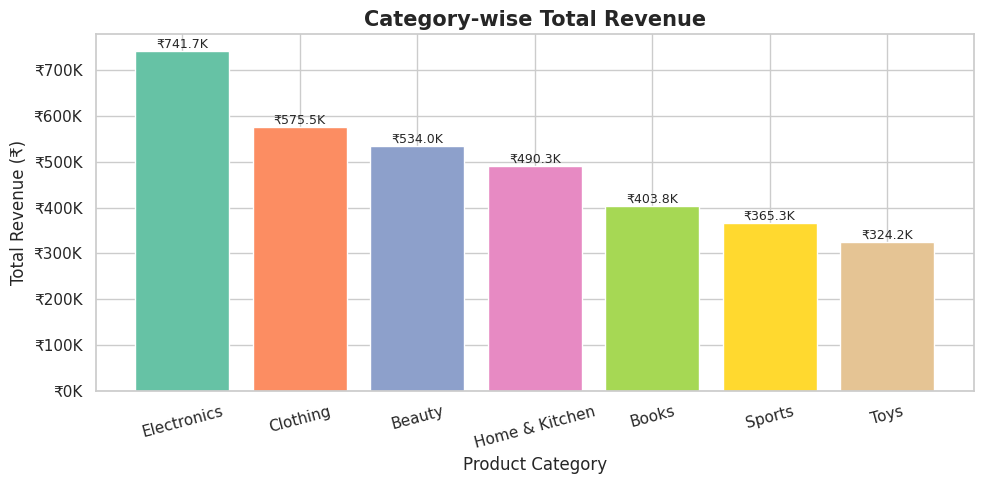

In [21]:
# ── Chart 1: Category-wise Revenue ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
cat_rev = df.groupby('Category')['FinalAmount'].sum().sort_values(ascending=False)
bars = ax.bar(cat_rev.index, cat_rev.values, color=sns.color_palette('Set2', len(cat_rev)))
ax.set_title('Category-wise Total Revenue', fontsize=15, fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Revenue (₹)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'₹{bar.get_height()/1000:.1f}K', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart1_category_revenue.png', dpi=150)
plt.show()

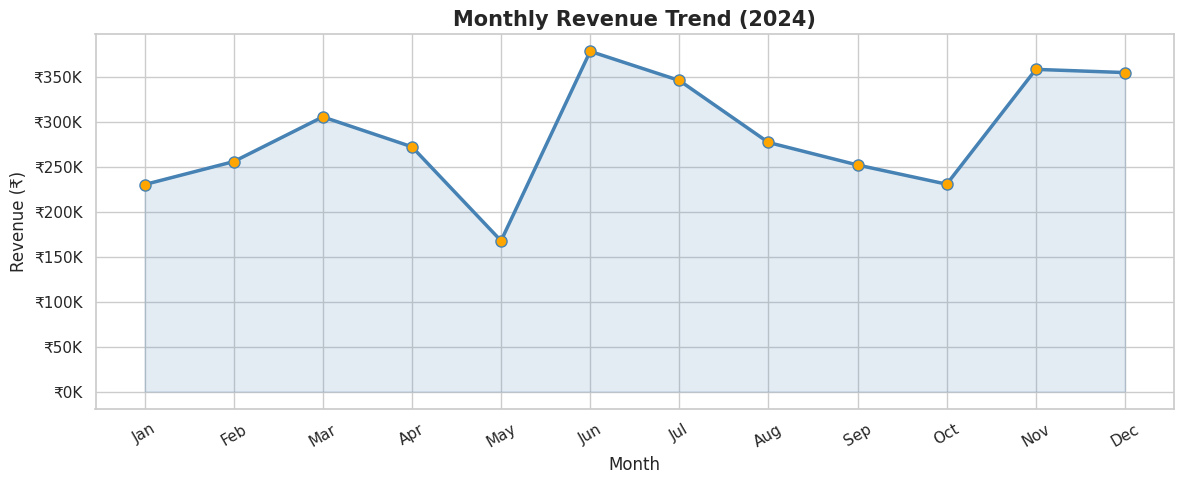

In [22]:
# ── Chart 2: Monthly Revenue Trend ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('MonthName')['FinalAmount'].sum().reindex(month_order).fillna(0)
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2.5,
        color='steelblue', markerfacecolor='orange', markersize=8)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')
ax.set_title('Monthly Revenue Trend (2024)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150)
plt.show()

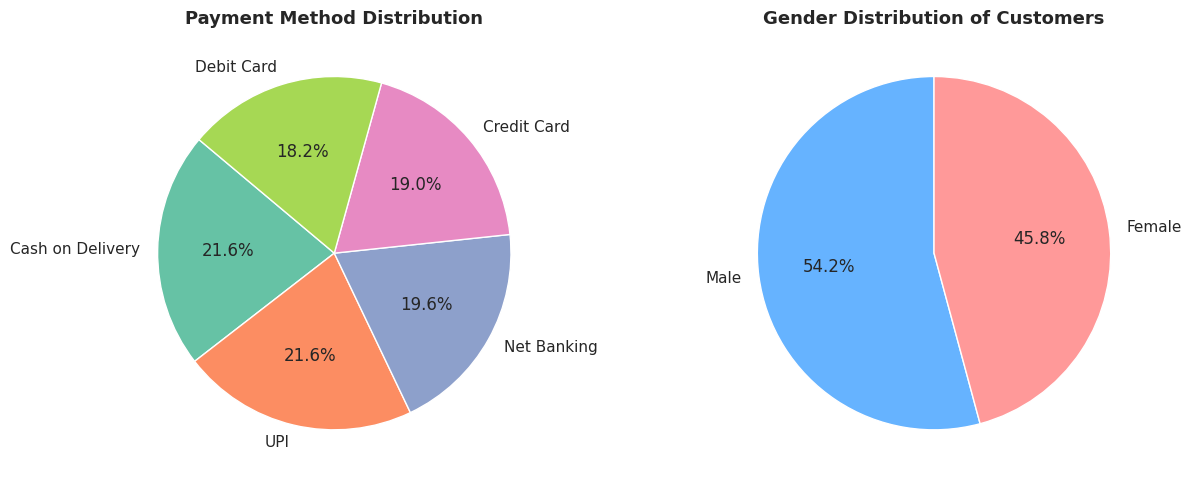

In [23]:
# ── Chart 3: Payment Method Distribution (Pie) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

payment_counts = df['PaymentMethod'].value_counts()
axes[0].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Set2', len(payment_counts)))
axes[0].set_title('Payment Method Distribution', fontsize=13, fontweight='bold')

# Gender distribution pie
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#66b3ff', '#ff9999'])
axes[1].set_title('Gender Distribution of Customers', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_pie_charts.png', dpi=150)
plt.show()

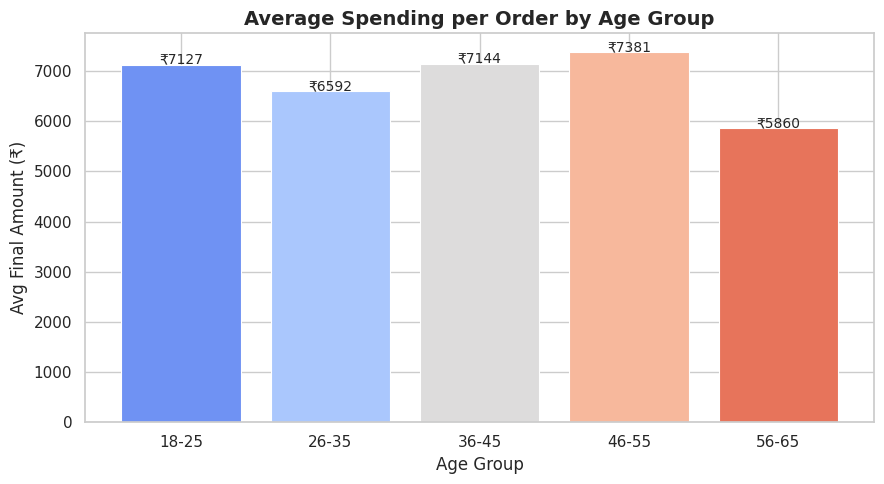

In [24]:
# ── Chart 4: Age Group vs Avg Spend ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
age_spend = df.groupby('AgeGroup', observed=True)['FinalAmount'].mean().sort_index()
colors = sns.color_palette('coolwarm', len(age_spend))
bars = ax.bar(age_spend.index.astype(str), age_spend.values, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Average Spending per Order by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Avg Final Amount (₹)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'₹{bar.get_height():.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart4_age_spending.png', dpi=150)
plt.show()

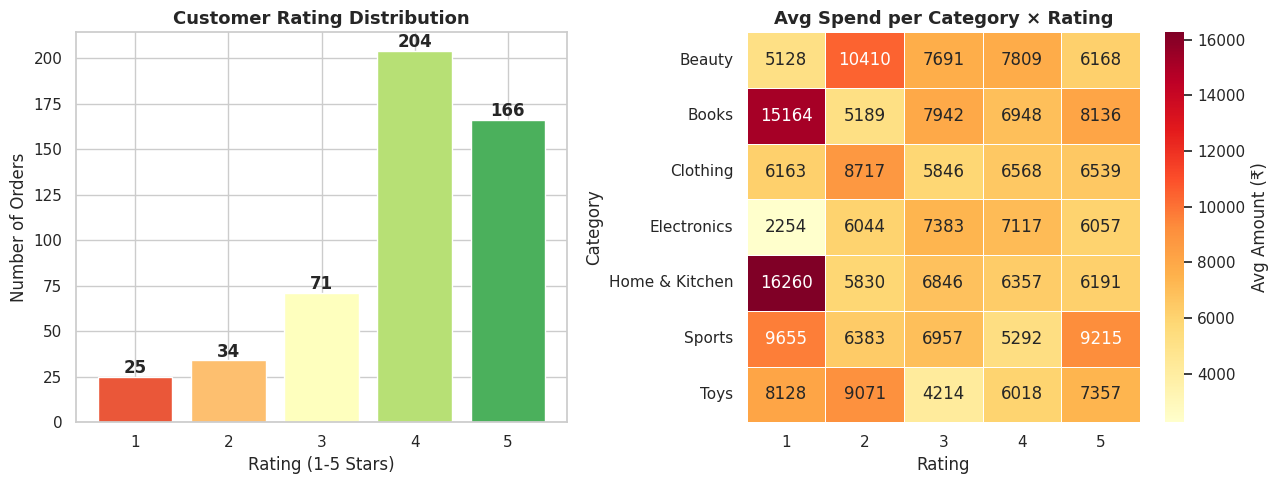

In [25]:
# ── Chart 5: Rating Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rating_counts = df['Rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=sns.color_palette('RdYlGn', 5), edgecolor='white')
axes[0].set_title('Customer Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (1-5 Stars)')
axes[0].set_ylabel('Number of Orders')
for i, (x, v) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(x, v + 2, str(v), ha='center', fontweight='bold')

# Heatmap: Category vs Rating avg
pivot = df.pivot_table(values='FinalAmount', index='Category', columns='Rating', aggfunc='mean').fillna(0)
sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Avg Amount (₹)'})
axes[1].set_title('Avg Spend per Category × Rating', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_ratings.png', dpi=150)
plt.show()

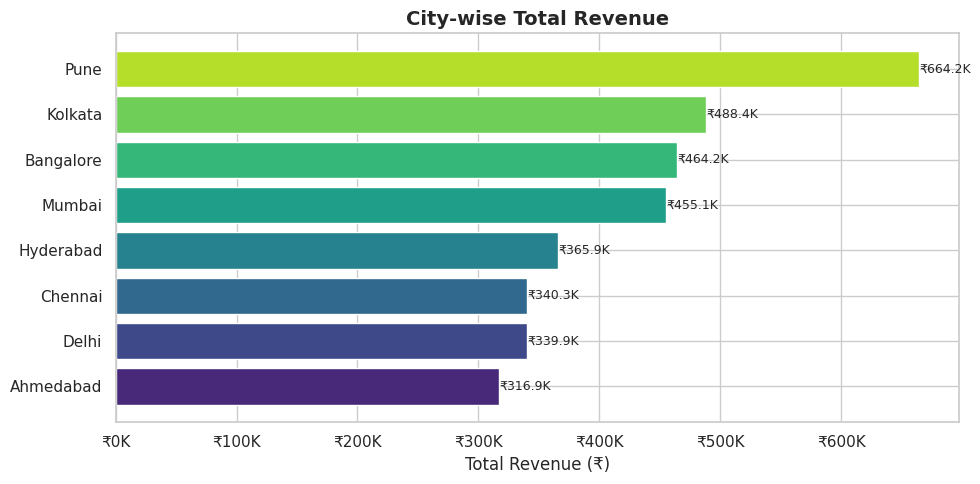

In [26]:
# ── Chart 6: City-wise Revenue ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
city_rev = df.groupby('City')['FinalAmount'].sum().sort_values()
colors = sns.color_palette('viridis', len(city_rev))
bars = ax.barh(city_rev.index, city_rev.values, color=colors)
ax.set_title('City-wise Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (₹)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'₹{bar.get_width()/1000:.1f}K', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart6_city_revenue.png', dpi=150)
plt.show()

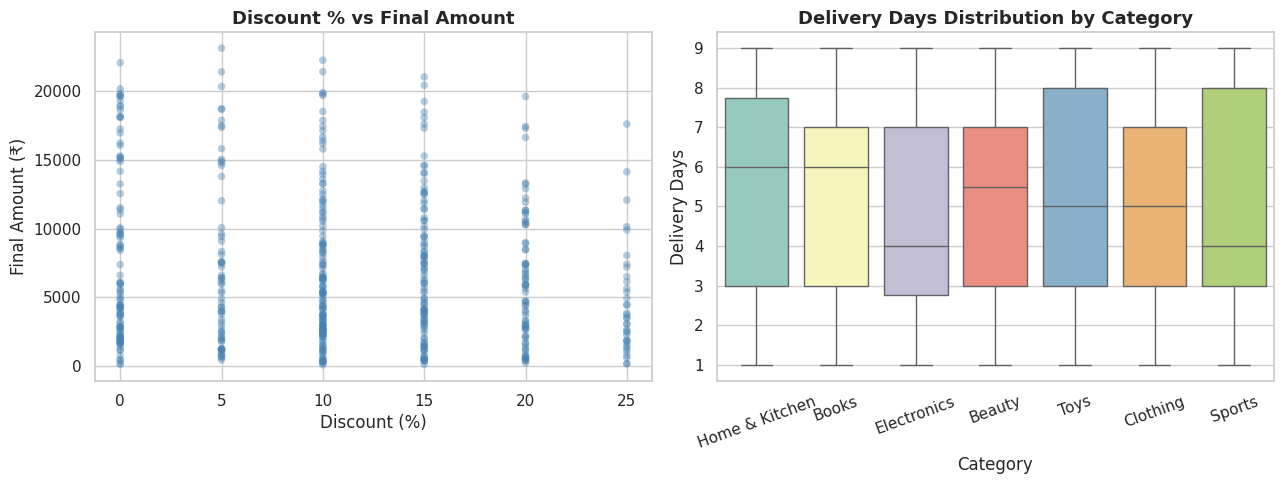

In [27]:
# ── Chart 7: Discount Impact on Final Amount ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: Discount vs Final Amount
axes[0].scatter(df['Discount(%)'], df['FinalAmount'], alpha=0.4,
                color='steelblue', edgecolors='none', s=30)
axes[0].set_title('Discount % vs Final Amount', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Final Amount (₹)')

# Box: Delivery Days by Category
sns.boxplot(data=df, x='Category', y='DeliveryDays', palette='Set3', ax=axes[1])
axes[1].set_title('Delivery Days Distribution by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Delivery Days')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('chart7_discount_delivery.png', dpi=150)
plt.show()

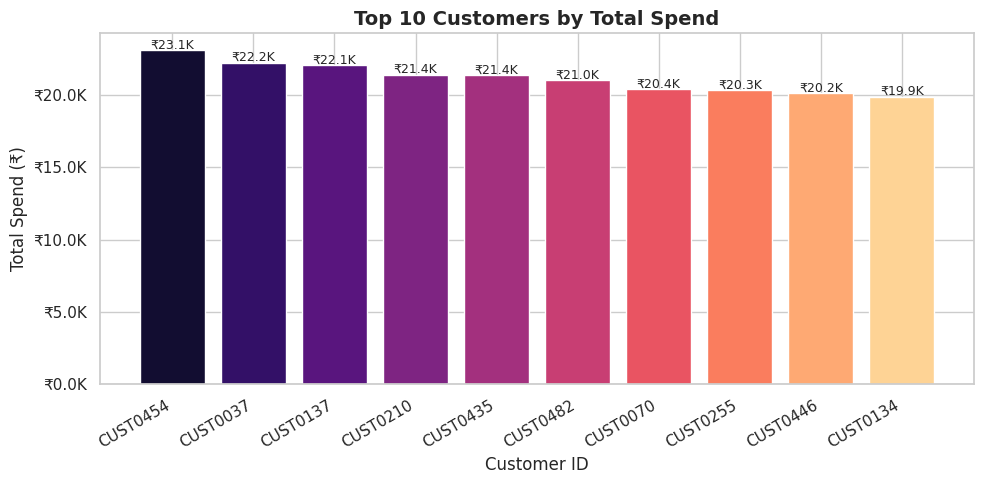

In [28]:
# ── Chart 8: Top Spending Customers ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
top_customers = df.groupby('CustomerID')['FinalAmount'].sum().sort_values(ascending=False).head(10)
ax.bar(range(len(top_customers)), top_customers.values,
       color=sns.color_palette('magma', 10), edgecolor='white')
ax.set_xticks(range(len(top_customers)))
ax.set_xticklabels(top_customers.index, rotation=30, ha='right')
ax.set_title('Top 10 Customers by Total Spend', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Total Spend (₹)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x/1000:.1f}K'))
for i, v in enumerate(top_customers.values):
    ax.text(i, v + 100, f'₹{v/1000:.1f}K', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart8_top_customers.png', dpi=150)
plt.show()

## 6. Key Insights & Findings

In [29]:
# Summary Statistics
total_orders = len(df)
total_revenue = df['FinalAmount'].sum()
avg_order_value = df['FinalAmount'].mean()
top_category = df.groupby('Category')['FinalAmount'].sum().idxmax()
top_city = df.groupby('City')['FinalAmount'].sum().idxmax()
most_popular_payment = df['PaymentMethod'].value_counts().idxmax()
avg_rating = df['Rating'].mean()
avg_delivery = df['DeliveryDays'].mean()

print("=" * 50)
print("       E-COMMERCE ANALYSIS SUMMARY REPORT")
print("=" * 50)
print(f"  Total Orders Analyzed       : {total_orders}")
print(f"  Total Revenue Generated     : ₹{total_revenue:,.2f}")
print(f"  Average Order Value         : ₹{avg_order_value:,.2f}")
print(f"  Top Revenue Category        : {top_category}")
print(f"  Top Revenue City            : {top_city}")
print(f"  Most Used Payment Method    : {most_popular_payment}")
print(f"  Average Customer Rating     : {avg_rating:.2f} / 5.0")
print(f"  Average Delivery Time       : {avg_delivery:.1f} days")
print("=" * 50)

       E-COMMERCE ANALYSIS SUMMARY REPORT
  Total Orders Analyzed       : 500
  Total Revenue Generated     : ₹3,434,821.87
  Average Order Value         : ₹6,869.64
  Top Revenue Category        : Electronics
  Top Revenue City            : Pune
  Most Used Payment Method    : Cash on Delivery
  Average Customer Rating     : 3.90 / 5.0
  Average Delivery Time       : 5.0 days


## 7. Conclusions

Based on the E-Commerce Customer Analysis, the following key conclusions were drawn:

1. **Top Category:** Electronics and Clothing generate the highest revenue, making them priority categories for promotions and stock management.

2. **Peak Sales Months:** Revenue peaks are observed mid-year (around June–August), suggesting seasonal buying patterns. Businesses should prepare inventory and offers before these months.

3. **Customer Age Behavior:** Customers aged **26–35** place the most orders. However, older age groups (46–55) tend to spend more per order, indicating higher purchasing power.

4. **Payment Preferences:** UPI and Credit Cards are the most preferred payment methods, showing strong digital payment adoption. Offering cashback on these methods could boost conversions.

5. **Customer Ratings:** The majority of orders (70%+) received 4–5 star ratings, reflecting good customer satisfaction. Books and Electronics received the highest ratings on average.

6. **Delivery Insights:** Average delivery time is around 5 days. Over 20% of deliveries take more than 6 days, which may negatively impact customer retention.

7. **Gender & City Trends:** Male and female customers show similar spending patterns. Mumbai and Delhi are the highest revenue-generating cities.

8. **High-Value Customers:** A small segment of customers contributes disproportionately to total revenue — targeting these with loyalty programs could be very effective.

---
*This analysis was performed using Python (Pandas, NumPy, Matplotlib, Seaborn) in Jupyter Notebook.*
